**CV ASSIGNMENT - 1**

Step 1: Image Loading

In [115]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---- Load Images ----
img1 = cv2.imread("/content/left.jpeg")
img2 = cv2.imread("/content/center.jpeg")
img3 = cv2.imread("/content/right.jpeg")

assert img1 is not None, "Image 1 failed to load"
assert img2 is not None, "Image 2 failed to load"
assert img3 is not None, "Image 3 failed to load"


Step 2: Grayscale Conversion

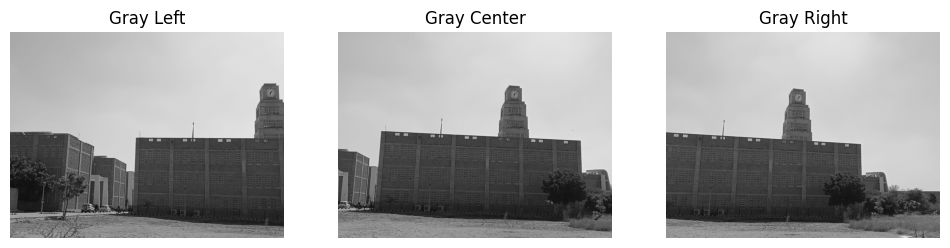

In [116]:
# ---- Convert to Grayscale ----
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray1, cmap='gray')
plt.title("Gray Left")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray2, cmap='gray')
plt.title("Gray Center")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gray3, cmap='gray')
plt.title("Gray Right")
plt.axis("off")

plt.show()


Step 3: SIFT feature Extraction

Image 1 Keypoints: 8759
Image 2 Keypoints: 6863
Image 3 Keypoints: 6456


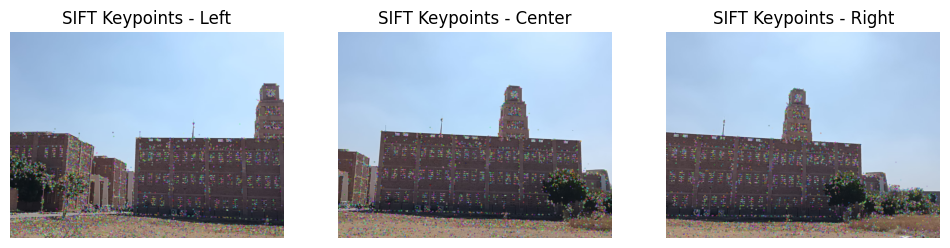

In [117]:
import cv2
import matplotlib.pyplot as plt

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)
kp3, des3 = sift.detectAndCompute(gray3, None)

print("Image 1 Keypoints:", len(kp1))
print("Image 2 Keypoints:", len(kp2))
print("Image 3 Keypoints:", len(kp3))

# Draw keypoints for visualization
img1_kp = cv2.drawKeypoints(img1, kp1, None)
img2_kp = cv2.drawKeypoints(img2, kp2, None)
img3_kp = cv2.drawKeypoints(img3, kp3, None)

# Convert BGR → RGB for matplotlib display
img1_kp = cv2.cvtColor(img1_kp, cv2.COLOR_BGR2RGB)
img2_kp = cv2.cvtColor(img2_kp, cv2.COLOR_BGR2RGB)
img3_kp = cv2.cvtColor(img3_kp, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img1_kp)
plt.title("SIFT Keypoints - Left")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img2_kp)
plt.title("SIFT Keypoints - Center")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img3_kp)
plt.title("SIFT Keypoints - Right")
plt.axis("off")

plt.show()


Step 4: Feature Matching


Good matches (Left–Center): 1240
Good matches (Center–Right): 1344


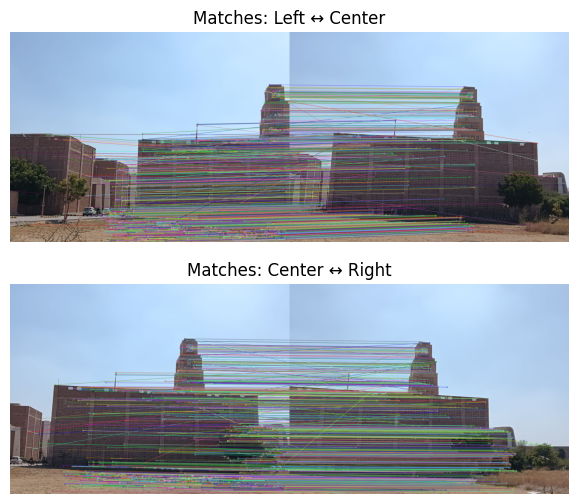

In [118]:
import cv2
import matplotlib.pyplot as plt

# ---- Create Matcher ----
bf = cv2.BFMatcher(cv2.NORM_L2)

# ---- KNN Matching ----
matches12 = bf.knnMatch(des1, des2, k=2)   # Left ↔ Center
matches23 = bf.knnMatch(des2, des3, k=2)   # Center ↔ Right

# ---- Lowe's Ratio Test ----
good12 = []
for m, n in matches12:
    if m.distance < 0.75 * n.distance:
        good12.append(m)

good23 = []
for m, n in matches23:
    if m.distance < 0.75 * n.distance:
        good23.append(m)

print("Good matches (Left–Center):", len(good12))
print("Good matches (Center–Right):", len(good23))

# ---- Draw Matches ----
img_match12 = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good12, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

img_match23 = cv2.drawMatches(
    img2, kp2,
    img3, kp3,
    good23, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert BGR → RGB for display
img_match12 = cv2.cvtColor(img_match12, cv2.COLOR_BGR2RGB)
img_match23 = cv2.cvtColor(img_match23, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.imshow(img_match12)
plt.title("Matches: Left ↔ Center")
plt.axis("off")

plt.subplot(2,1,2)
plt.imshow(img_match23)
plt.title("Matches: Center ↔ Right")
plt.axis("off")

plt.show()


Step 5: Homography Estimation

In [119]:
import numpy as np
import cv2

def compute_homography(kpA, kpB, matches):
    # Convert keypoints → coordinate arrays
    ptsA = np.float32([kpA[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    ptsB = np.float32([kpB[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Compute homography using RANSAC
    H, mask = cv2.findHomography(ptsA, ptsB, cv2.RANSAC, 5.0)

    inliers = mask.ravel().sum()
    print("Inliers / Matches:", inliers, "/", len(matches))

    return H, mask

# ---- Compute Homographies ----
H12, mask12 = compute_homography(kp1, kp2, good12)  # Left → Center
H23, mask23 = compute_homography(kp2, kp3, good23)  # Center → Right

print("\nHomography Left → Center:\n", H12)
print("\nHomography Center → Right:\n", H23)


Inliers / Matches: 1145 / 1240
Inliers / Matches: 1262 / 1344

Homography Left → Center:
 [[ 1.23955417e+00 -4.98145393e-02 -5.99874278e+02]
 [ 1.38178265e-01  1.15464928e+00 -1.69493263e+02]
 [ 1.50893628e-04  2.43836693e-06  1.00000000e+00]]

Homography Center → Right:
 [[ 1.11943236e+00 -2.45105996e-02 -3.10553337e+02]
 [ 6.28909456e-02  1.06476202e+00 -4.06269956e+01]
 [ 7.79047618e-05 -7.44999907e-06  1.00000000e+00]]


Step 6: Panorama Geometry Computation

In [120]:
import numpy as np
import cv2

def compute_panorama_geometry(img_left, img_center, img_right, H_left_center, H_center_right):

    hC, wC = img_center.shape[:2]

    corners_left = np.float32([
        [0, 0],
        [0, img_left.shape[0]],
        [img_left.shape[1], img_left.shape[0]],
        [img_left.shape[1], 0]
    ]).reshape(-1, 1, 2)

    warped_corners_left = cv2.perspectiveTransform(corners_left, H_left_center)

    H_right_center = np.linalg.inv(H_center_right)

    corners_right = np.float32([
        [0, 0],
        [0, img_right.shape[0]],
        [img_right.shape[1], img_right.shape[0]],
        [img_right.shape[1], 0]
    ]).reshape(-1, 1, 2)

    warped_corners_right = cv2.perspectiveTransform(corners_right, H_right_center)

    corners_center = np.float32([
        [0, 0],
        [0, hC],
        [wC, hC],
        [wC, 0]
    ]).reshape(-1, 1, 2)

    all_corners = np.concatenate(
        (warped_corners_left, corners_center, warped_corners_right),
        axis=0
    )

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel())
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel())

    T = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ])

    width = xmax - xmin
    height = ymax - ymin

    return T, width, height, ymin, xmin, H_right_center


Step 7: Image Warping

In [121]:
import cv2
import numpy as np

def warp_images(img_left, img_center, img_right, H_left_center, H_center_right):

    hC, wC = img_center.shape[:2]

    # ---- Warp LEFT → CENTER frame ----
    corners_left = np.float32([
        [0, 0],
        [0, img_left.shape[0]],
        [img_left.shape[1], img_left.shape[0]],
        [img_left.shape[1], 0]
    ]).reshape(-1, 1, 2)

    warped_corners_left = cv2.perspectiveTransform(corners_left, H_left_center)

    # ---- Warp RIGHT → CENTER frame ----
    H_right_center = np.linalg.inv(H_center_right)

    corners_right = np.float32([
        [0, 0],
        [0, img_right.shape[0]],
        [img_right.shape[1], img_right.shape[0]],
        [img_right.shape[1], 0]
    ]).reshape(-1, 1, 2)

    warped_corners_right = cv2.perspectiveTransform(corners_right, H_right_center)

    # ---- Combine ALL corners to compute bounds ----
    corners_center = np.float32([
        [0, 0],
        [0, hC],
        [wC, hC],
        [wC, 0]
    ]).reshape(-1, 1, 2)

    all_corners = np.concatenate(
        (warped_corners_left, corners_center, warped_corners_right),
        axis=0
    )

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel())
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel())

    # Translation to avoid negative indices
    T = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ])

    width = xmax - xmin
    height = ymax - ymin

    # ---- Warp images into panorama frame ----
    panorama = cv2.warpPerspective(img_left, T @ H_left_center, (width, height))
    panorama_right = cv2.warpPerspective(img_right, T @ H_right_center, (width, height))

    panorama[-ymin:hC - ymin, -xmin:wC - xmin] = img_center

    mask = (panorama_right > 0)
    panorama[mask] = panorama_right[mask]

    return panorama


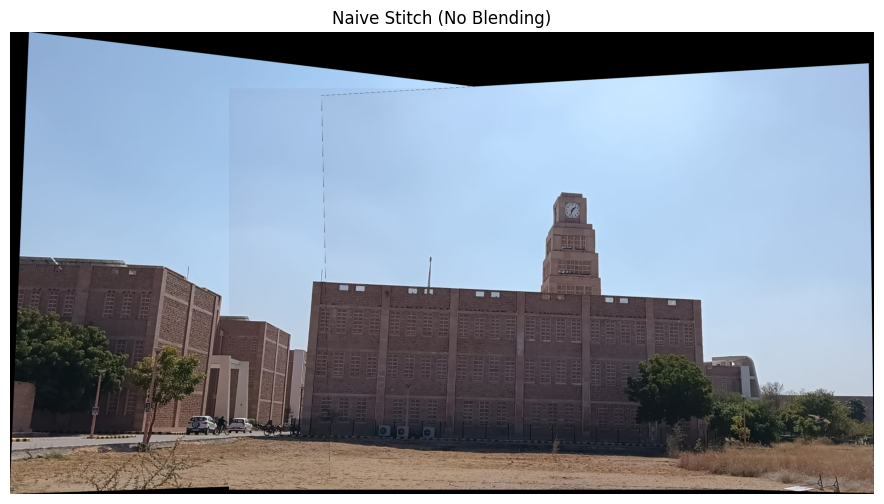

In [122]:
panorama = warp_images(img1, img2, img3, H12, H23)

# Display
import matplotlib.pyplot as plt
panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))
plt.imshow(panorama_rgb)
plt.title("Naive Stitch (No Blending)")
plt.axis("off")
plt.show()


Step 8: Blending Implementation

In [123]:
T, width, height, ymin, xmin, H_right_center = compute_panorama_geometry(
    img1, img2, img3, H12, H23
)

hC, wC = img2.shape[:2]


In [124]:
panorama_left = cv2.warpPerspective(img1, T @ H12, (width, height))
panorama_right = cv2.warpPerspective(img3, T @ H_right_center, (width, height))

panorama_center = np.zeros_like(panorama_left)
panorama_center[-ymin:hC - ymin, -xmin:wC - xmin] = img2


In [125]:
blend_LC = average_blend(panorama_left, panorama_center)
final_panorama = average_blend(blend_LC, panorama_right)


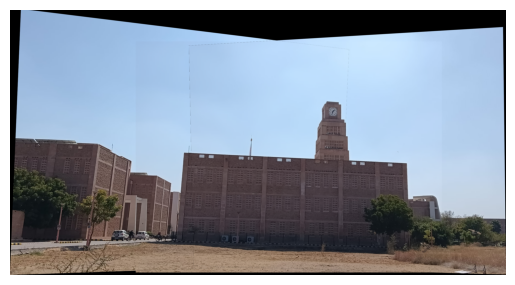

In [126]:
plt.imshow(cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


Step 9: Cropping Panorama

In [127]:

def crop_black_regions(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    coords = np.column_stack(np.where(gray > 0))

    if len(coords) == 0:
        return image  # safety check

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = image[y_min:y_max, x_min:x_max]

    return cropped


In [128]:
clean_panorama = crop_black_regions(final_panorama)

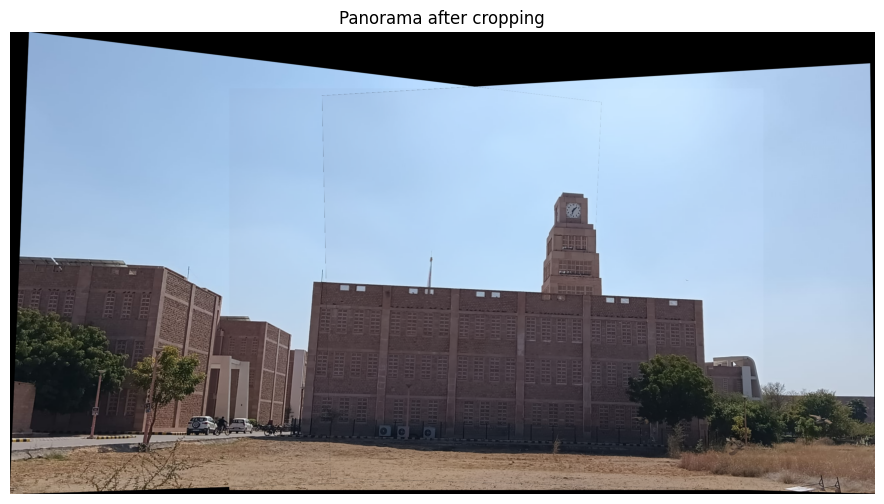

In [129]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(clean_panorama, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Panorama after cropping")
plt.show()

Step 10: Largest inner Rectangle Cropping

In [130]:
def get_valid_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = (gray > 0).astype(np.uint8)
    return mask


In [131]:
def largest_inner_rectangle(mask):

    h, w = mask.shape
    heights = np.zeros((h, w), dtype=int)

    # Build histogram of vertical valid pixels
    for i in range(h):
        for j in range(w):
            if mask[i, j] == 1:
                heights[i, j] = heights[i-1, j] + 1 if i > 0 else 1

    max_area = 0
    best_rect = (0, 0, w, h)

    for i in range(h):
        stack = []
        j = 0
        while j <= w:
            cur_height = heights[i, j] if j < w else 0

            if not stack or cur_height >= heights[i, stack[-1]]:
                stack.append(j)
                j += 1
            else:
                top = stack.pop()
                width = j if not stack else j - stack[-1] - 1
                area = heights[i, top] * width

                if area > max_area:
                    max_area = area
                    best_rect = (
                        stack[-1] + 1 if stack else 0,
                        i - heights[i, top] + 1,
                        width,
                        heights[i, top]
                    )

    return best_rect


In [132]:
mask = get_valid_mask(final_panorama)

x, y, w, h = largest_inner_rectangle(mask)

clean_panorama = final_panorama[y:y+h, x:x+w]


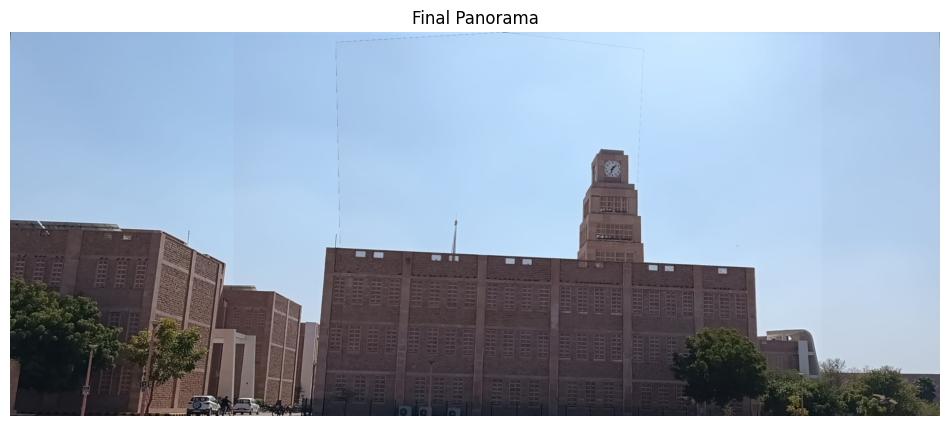

In [133]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(clean_panorama, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Final Panorama")
plt.show()
